In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from concurrent.futures import ThreadPoolExecutor, as_completed

from scipy.signal import butter, filtfilt
from scipy.stats import skew, kurtosis

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# Setup

## 1. DEAP

### 1.1 Locate and Unzip

In [2]:
target_dir = None if os.path.exists("./deap-dataset") else '/content/gdrive/MyDrive/'
dataset_dir = "./deap-dataset" if os.path.exists("./deap-dataset") else f"{target_dir}deap-dataset"

print(target_dir)
print(dataset_dir)

/content/gdrive/MyDrive/
/content/gdrive/MyDrive/deap-dataset


In [3]:
# Mount google drive directory
if target_dir is not None:
    from google.colab import drive
    import requests

    drive.mount('/content/gdrive/')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


In [4]:
if target_dir is not None and os.path.exists(target_dir):
    os.chdir(target_dir)
    print(f"Changed directory to: {os.getcwd()}")

elif target_dir is not None:
    print(f"Error: Directory not found: {target_dir}. Please ensure Google Drive is mounted and the path is correct.")
    exit(1)

if not os.path.exists(dataset_dir):
    os.system(f"unzip deap-dataset.zip -d {dataset_dir}")
    print("deap-dataset.zip extracted.")

else:
    print("deap-dataset directory already exists. Skipping extraction.")

Changed directory to: /content/gdrive/MyDrive
deap-dataset directory already exists. Skipping extraction.


The `deap-dataset.zip` archive has been extracted, creating a directory named `deap-dataset/` which contains all the dataset files and subdirectories, including `data_preprocessed_python/`.

### 1.2 load sub

The videos are in the order of Experiment_id, so not in the order of presentation. This means the first video is the same for each participant.

In [5]:
if os.path.exists(target_dir):
    os.chdir(target_dir)
    print(f"Changed directory to: {os.getcwd()}")

else:
    print(f"Error: Directory not found: {os.path.join(os.getcwd(), target_dir)}. Please ensure 'deap-dataset.zip' was extracted correctly and contains 'data_preprocessed_python/'.")

Changed directory to: /content/gdrive/MyDrive


We've now navigated into the `deap-dataset/data_preprocessed_python/` directory, where the individual subject data files (`sXX.dat`) are located.

In [6]:
def load_subjects_data(subject_id_str):
  """Loads data for a specific subject from a .dat file."""

  file_name = f'{dataset_dir}/data_preprocessed_python/s{subject_id_str}.dat'

  with open(file_name, 'rb') as file:
    subject = pickle.load(file, encoding='latin1')

  return subject

In [7]:
# Example usage: Load data for subject '01'

subject_id = '01'
subject = load_subjects_data(subject_id)

print(f"Successfully loaded data for subject {subject_id}.")

Successfully loaded data for subject 01.


In [8]:
subject.keys()

dict_keys(['labels', 'data'])

The `subject` dictionary contains two main keys: 'labels' and 'data'.

*   **'labels'**: This typically contains the self-assessment scores (valence, arousal, dominance, liking) for each video watched by the participant.
*   **'data'**: This holds the physiological signal data (e.g., EEG, EOG, EMG, GSR, respiration, temperature) recorded during the experiment.

In [9]:
subject['data'].shape

(40, 40, 8064)

The shape of $\text{subject}[\text{data}]$ is $(40, 40, 8064)$:

*   $40$: Represents the $40$ experimental trials (videos) for this participant.
*   $40$: Represents the $40$ physiological channels (e.g., $32$ EEG, $8$ peripheral).
*   $8064$: Represents the number of data points (samples) per channel per trial. Given a sampling rate of $128\ \text{Hz}$ and a trial duration of $63$ seconds, this corresponds to $128 \text{ samples/second} * 63 \text{ seconds} = 8064 \text{ samples}$.

In [10]:
subject['labels'].shape

(40, 4)

The shape of $\text{subject}[\text{labels}]$ is $(40, 4)$:

*   $40$: Represents the 40 experimental trials (videos).
*   $4$: Represents the 4 self-assessment scores: Valence, Arousal, Dominance, and Liking, typically rated on a scale of 1-9.

In [11]:
del(subject)

### 1.3. Cache into memory

In [12]:
global subject_data
subjects_data = []

global subject_labels
subjects_labels = []

In [13]:
def print_progress_bar(current, total, length=30, after:str = "", new_line=False) -> None:
    filled = int(length * current / total)
    bar = "*" * filled + "-" * (length - filled)
    
    print(f"\r[{bar}] {current}/{total}\t {after}", end="\n" if new_line else "" , flush=True)
    
    if current == total:
        print()

In [14]:
warnings = []
os.chdir(f"{dataset_dir}/data_preprocessed_python")

for subject in range(1, 33):
    
    filename = f"s{subject:02d}.dat"
    try:
        # Open binary file
        with open(filename, "rb") as f:
            dataset = pickle.load(f, encoding="latin1")
        
        # load features
        subjects_data.append(dataset["data"])
        
        # load labels
        subjects_labels.append(dataset["labels"])
        
        print_progress_bar(subject, 32)
        
    except (EOFError, pickle.UnpicklingError, OSError) as e:
        warnings.append(
            f"WARNING: skipping s{subject:02d}.dat ({e})" if len(warnings) < 1 else f"s{subject:02d}.dat ({e})"
        )
        
        print_progress_bar(subject, 32, after=', '.join(warnings), new_line=True)
        continue

[**----------------------------] 3/32	 WARNING: skipping s03.dat (Ran out of input)
[********----------------------] 9/32	 WARNING: skipping s03.dat (Ran out of input), s09.dat (Ran out of input)
[***********-------------------] 12/32	 WARNING: skipping s03.dat (Ran out of input), s09.dat (Ran out of input), s12.dat (Ran out of input)
[***************---------------] 17/32	 WARNING: skipping s03.dat (Ran out of input), s09.dat (Ran out of input), s12.dat (Ran out of input), s17.dat (Ran out of input)
[******************------------] 20/32	 WARNING: skipping s03.dat (Ran out of input), s09.dat (Ran out of input), s12.dat (Ran out of input), s17.dat (Ran out of input), s20.dat (Ran out of input)
[****************************--] 30/32	 WARNING: skipping s03.dat (Ran out of input), s09.dat (Ran out of input), s12.dat (Ran out of input), s17.dat (Ran out of input), s20.dat (Ran out of input), s30.dat (Ran out of input)
[******************************] 32/32	 


In [15]:
print(f"Cached {len(subjects_data)} subjects successfully.")

Cached 26 subjects successfully.


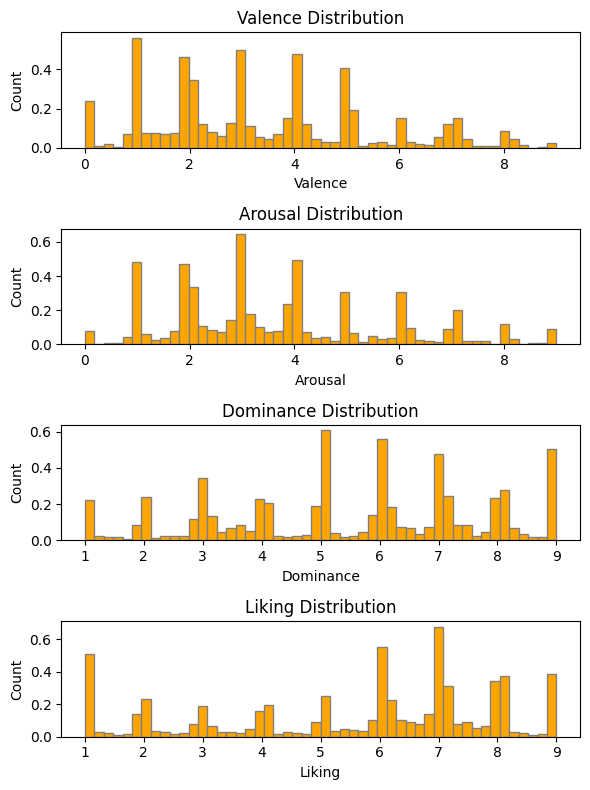

In [16]:
fig, axes = plt.subplots(4, figsize=(6, 8))
labels_data = np.vstack(subjects_labels)

for i, label in enumerate(["Valence", "Arousal", "Dominance", "Liking"]):
    axes[i].hist(
        x=labels_data[:, i], 
        bins=50,
        density=True,
        edgecolor="grey",
        facecolor="orange"
    )
    axes[i].set_xlabel(label)
    axes[i].set_ylabel("Count")
    axes[i].set_title(f"{label} Distribution")

plt.tight_layout()
plt.show()

## 3. Plotting

In [17]:
def plot_classifier_metrics(df, title="Classifier Comparison") -> None:
    # Aggregated to ensure exactly 5 bars per chart are plotted per the criteria
    df_agg = df.groupby("classifier", as_index=False).mean(numeric_only=True)
    
    names = df_agg["classifier"].tolist()

    metrics = {
        "Accuracy": df_agg["accuracy"].tolist(),
        "Precision": df_agg["precision"].tolist(),
        "Recall": df_agg["recall"].tolist(),
        "F1": df_agg["f1"].tolist(),
    }

    x = np.arange(len(df_agg))
    width = 0.2

    plt.figure(figsize=(10, 5))

    for i, (metric, values) in enumerate(metrics.items()):
        plt.bar(x + i * width, values, width=width, label=metric)

    plt.xticks(x + width * 1.5, names)
    plt.title(title)
    plt.xlabel("Classifier")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()

# Settings

All global constants and variables used

`Fs`: sampling rate/frequency ($128\ \text{Hz}$).

In [18]:
Fs = 128 # Hz

`label_column`: zero-based index of self-assessment scores to classify ($ 0 = \text{Valence} $).

In [19]:
label_column = 0

`segment_length`: each $60\large s$ trial is split into four $15\large s$ windows.

In [20]:
segment_length = 15 * Fs

`cpu_use_percentage`: Percentage of the CPU used by worker threads

In [21]:
cpu_use_percentage = 0.80

`b, a`: 4th-order Butterworth band-pass filter (0.5–45 Hz), the typical EEG range.

In [22]:
b, a = butter(
    4, # 4th-order
    [0.5/(Fs/2), 45/(Fs/2)], # [0.5–45 Hz], Typical EEG range
    btype='bandpass'
)

Labels and shared accumulator for the comparison table at the end.

In [23]:
global results
results = []

global segment_splits
segment_splits = []

global Xtrain, Xtest
global Ytrain, Ytest

In [24]:
classifier_labels = [
    "SVM",
    "KNN",
    "Logistic Regression",
    "Decision Tree",
    "LDA"
]

segment_labels = [
    "0-15 s",
    "15-30 s",
    "30-45 s",
    "45-60 s"
]

# Pre-processing

In [25]:
X = np.array([])

Y={
    "valence": [],
    "arousal": [],
    "dominance": [],
    "liking": []
}

### Dimensionality Reduction & Train/Test Split

PCA reduces the feature space to $20$ components before classification, to ease the curse of dimensionality. The reduced data is then split $70/30$ into train and test sets, stratified by label so both sets keep the same class balance.

In [26]:
def pca(Xtrain, n_comp=20) -> tuple:
    pca_model = PCA(n_components=n_comp)
    Xtrain = pca_model.fit_transform(Xtrain)
    
    return Xtrain

In [27]:
def split_traintest(X_red, Y) -> tuple:
    """Splits train and test data from normalised dataset"""

    Xtrain, Xtest, Ytrain, Ytest = train_test_split(
        X_red, Y, test_size=0.30, random_state=42, stratify=Y
    )
    
    return Xtrain, Xtest, Ytrain, Ytest

### Feature Extraction

For a single trial, `runTrial()`:

1. Band-pass filters all 32 EEG channels (using the filter defined in Settings).
2. Keeps only the current 15-second segment.
3. Computes 6 statistical features per channel — mean, std, variance, RMS, skewness, kurtosis.

It returns the resulting feature vector together with the trial's label, and relies on `data`, `trial`, `segment`, and `current_labels` being set by the loop that calls it.

In [28]:
def runTrial(trial, data, segment, valence_labels, arousal_labels, dominance_labels, liking_labels) -> tuple:
    eeg = data[trial, 0:32, :]

    # Bandpass filter: 0.5-45 Hz, 4th-order Butterworth
    eeg_filt = np.zeros_like(eeg)
    for ch in range(32):
        eeg_filt[ch, :] = filtfilt(b, a, eeg[ch, :])


    # Slice current segment
    start_idx = (segment * segment_length)+384
    end_idx = ((segment + 1) * segment_length)+384
    eeg_seg = eeg_filt[:, start_idx:end_idx]


    # Extract 6 statistical features per channel
    feature_vector = []
    for ch in range(32):
        x = eeg_seg[ch, :]
        
        feature_vector.extend([
            np.mean(x),
            np.std(x),
            np.var(x),
            np.sqrt(np.mean(x**2)),
            skew(x),
            kurtosis(x)
        ])
    
    
    return feature_vector, valence_labels[trial], arousal_labels[trial], dominance_labels[trial], liking_labels[trial]

### Main loop

For each of the $4$ segments: loads every subject's `.dat` file, extracts features for all $40$ trials via `runTrial()`, then standardizes the resulting feature matrix $X$ with `StandardScaler`. After this cell runs, $X$ and $Y$ hold the data for the last segment processed.

In [29]:
def _process_subject(data, labels, segment: int) -> tuple:
    v_labels = np.where(labels[:,0] > 5, 1, 0)
    a_labels = np.where(labels[:,1] > 5, 1, 0)
    d_labels = np.where(labels[:,2] > 5, 1, 0)
    l_labels = np.where(labels[:,3] > 5, 1, 0)
    
    
    x,v,a,d,l = [],[],[],[],[]
    for trial in range(40):

        features, valence, arousal, dominance, liking = runTrial(
            trial,
            data,
            segment,
            v_labels,
            a_labels,
            d_labels,
            l_labels,
        )

        x.append(features)

        v.append(valence)
        a.append(arousal)
        d.append(dominance)
        l.append(liking)
        
    return x, v, a, d, l

In [30]:
def pre_process() -> None:
    # PREPROCESS ALL SEGMENTS — Feature Extraction + PCA + Split
    for segment in range(4):

        print("\n")

        X = []

        # Dictionary to hold all label arrays
        Y = {
            "valence": [],
            "arousal": [],
            "dominance": [],
            "liking": []
        }

        with ThreadPoolExecutor(max_workers=round(os.cpu_count() * cpu_use_percentage)) as executor:
            futures = {
                executor.submit(_process_subject, subjects_data[subj_idx], subjects_labels[subj_idx], segment): subj_idx
                    for subj_idx in range(len(subjects_data))
            }
            
            for i, future in enumerate(as_completed(futures), start=1):
                X_sub, v_sub, a_sub, d_sub, l_sub = future.result()
                
                X.extend(X_sub)
                Y["valence"].extend(v_sub)
                Y["arousal"].extend(a_sub)
                Y["dominance"].extend(d_sub)
                Y["liking"].extend(l_sub)

                print_progress_bar(i, len(subjects_data), after=f"SEGMENT {segment + 1}")

        # NORMALISATION
        X = np.array(X)
        for key in Y:
            Y[key] = np.array(Y[key])

        # PCA
        X = pca(X, 20)

        # Save the segment
        segment_splits.append((X, Y))

    print(f"\nPreprocessing complete.")

In [31]:
print("\n\nStarting label and feature pre-processing",end="")

pre_process()



Starting label and feature pre-processing

[******************************] 26/26	 SEGMENT 1


[******************************] 26/26	 SEGMENT 2


[******************************] 26/26	 SEGMENT 3


[******************************] 26/26	 SEGMENT 4

Preprocessing complete.


# Classifiers
---

Five classifiers are trained on the same `Xtrain`/`Ytrain` split and compared on the same `Xtest`/`Ytest`. Each one lives in its own cell below: it trains, predicts, scores itself with `evaluate_metrics`, and prints its own result — so you can run just one cell to see just that classifier's result, or run the whole notebook to get all of them.

## Evaluation Metrics

Computes accuracy, precision, recall, and $F1$ from the confusion matrix. Every classifier below is scored with this same function, so results are directly comparable.

In [32]:
scorers = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
}

In [33]:
def evaluate_metrics(clf, Features, Labels) -> tuple:
    scores = {
        name: np.median(cross_val_score(clf, Features, Labels, cv=10, scoring=scorer))
        for name, scorer in scorers.items()
    }
    return scores["accuracy"], scores["precision"], scores["recall"], scores["f1"]

## Model Runner
Shared runner method to run all classifiers

In [34]:
def run_model(model, segments_split, c_name="Classifier") -> []:
    pred = []

    with ThreadPoolExecutor(max_workers=round(os.cpu_count() * 0.80)) as executor:
        futures = {
            executor.submit(evaluate_metrics, model, segments_split[segment][0], y_values): (segment, label_name)
                for segment in range(4)
                for label_name, y_values in segments_split[segment][1].items()
        }

        for future in as_completed(futures):
            segment, label_name = futures[future]
            acc, prec, rec, f1 = future.result()

            pred.append({
                "segment": segment+1,
                "label": label_name,
                "classifier": c_name,
                "accuracy": acc,
                "precision": prec,
                "recall": rec,
                "f1": f1
            })

    return pred

## I. SVM (Support Vector Model)

Finds the hyperplane (here, via an RBF kernel) that best separates the two valence classes, maximizing the margin between them.

In [74]:
mdl = SVC(kernel='rbf')

In [ ]:
result = run_model(mdl, segment_splits, "SVM")

result_table = pd.DataFrame(result)
results.extend(result)

print(len(results))

del(mdl)
del(result)


--- Valence ---
 segment   label classifier  accuracy  precision  recall  f1
       1 valence        SVM  0.788462        0.0     0.0 0.0
       2 valence        SVM  0.788462        0.0     0.0 0.0
       3 valence        SVM  0.788462        0.0     0.0 0.0
       4 valence        SVM  0.788462        0.0     0.0 0.0


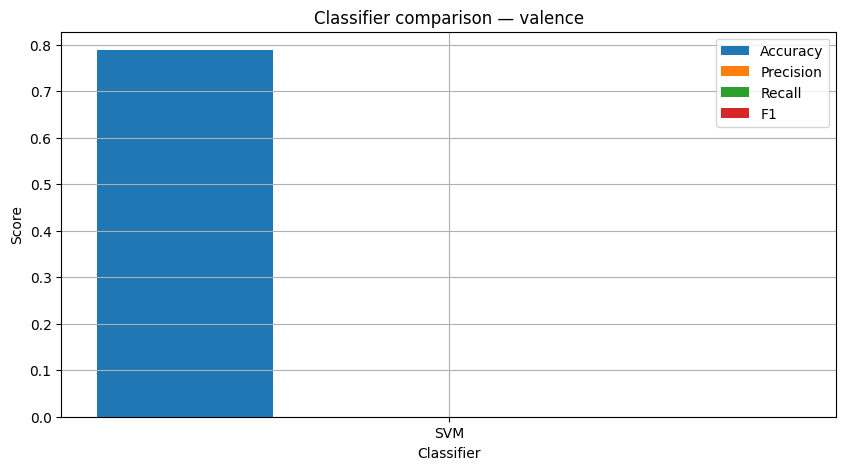


--- Arousal ---
 segment   label classifier  accuracy  precision  recall  f1
       1 arousal        SVM  0.769231        0.0     0.0 0.0
       2 arousal        SVM  0.769231        0.0     0.0 0.0
       3 arousal        SVM  0.769231        0.0     0.0 0.0
       4 arousal        SVM  0.769231        0.0     0.0 0.0


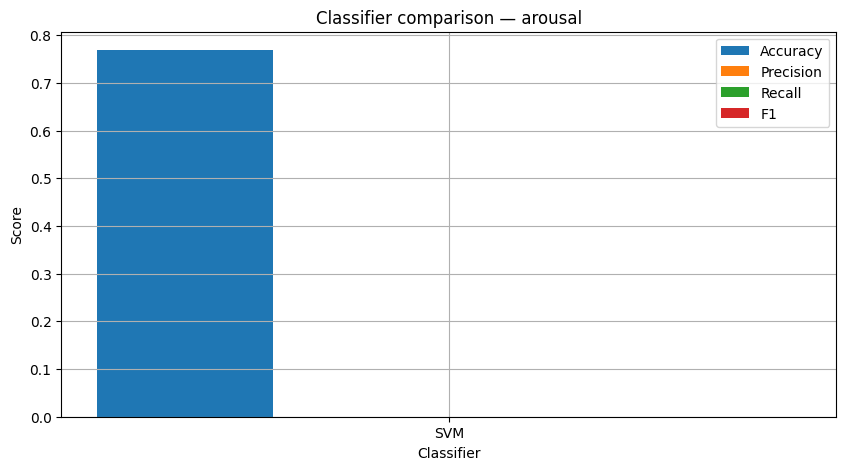


--- Dominance ---
 segment     label classifier  accuracy  precision   recall       f1
       1 dominance        SVM  0.543269   0.594637 0.862471 0.703937
       2 dominance        SVM  0.581731   0.611122 0.878788 0.735551
       3 dominance        SVM  0.567308   0.605114 0.900932 0.723878
       4 dominance        SVM  0.600962   0.619431 0.901166 0.739507


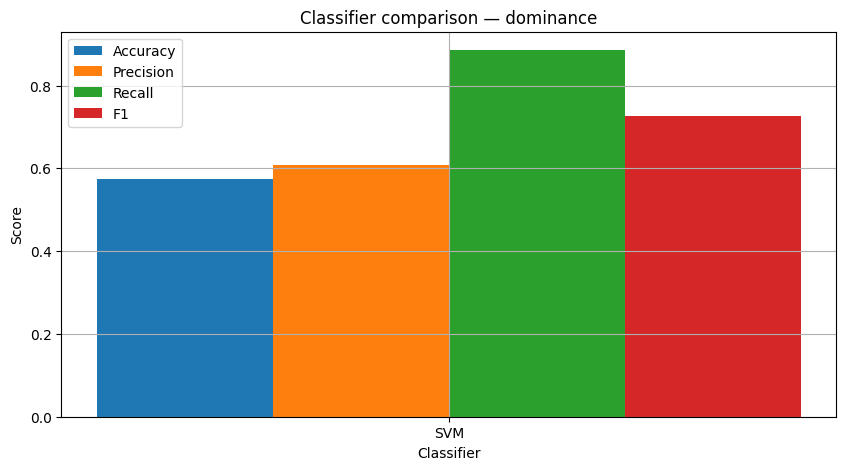


--- Liking ---
 segment  label classifier  accuracy  precision   recall       f1
       1 liking        SVM  0.644231   0.658960 0.971014 0.779964
       2 liking        SVM  0.658654   0.663462 1.000000 0.794193
       3 liking        SVM  0.658654   0.663462 0.978261 0.794193
       4 liking        SVM  0.649038   0.662613 0.985507 0.787162


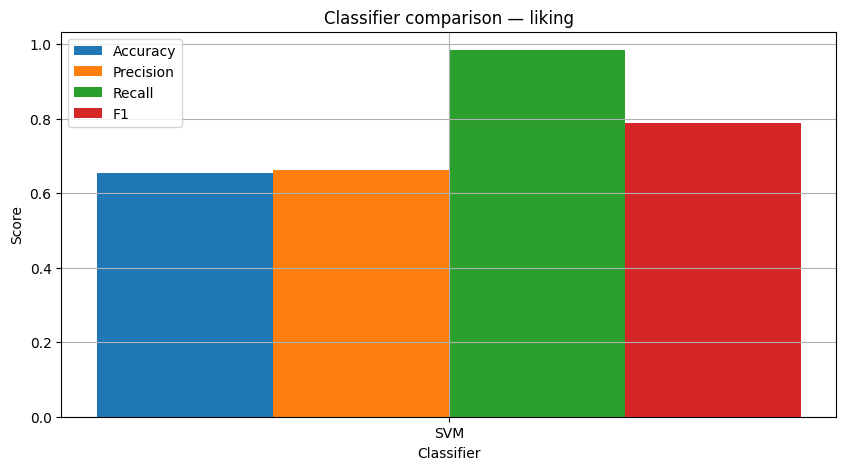

In [ ]:
# Build DataFrame from results
display_table = result_table.copy()

# Print and plot per label
for label in ["valence", "arousal", "dominance", "liking"]:
    subset = display_table[display_table["label"] == label]
    
    print(f"\n--- {label.capitalize()} ---")
    print(subset.to_string(index=False))
    
    plot_classifier_metrics(subset, title=f"Classifier comparison — {label}")

## II. KNN ($\small k$-th Nearest Neighbor)

Classifies each test sample by majority vote among its $5$ nearest neighbors in the training set (Euclidean distance in the $20$-component PCA space).

In [ ]:
mdl = KNeighborsClassifier(n_neighbors=5)

In [ ]:
result = run_model(mdl, segment_splits, "KNN")

result_table = pd.DataFrame(result)
results.extend(result)

print(len(results))

del(mdl)
del(result)

32



--- Valence ---
 segment   label classifier  accuracy  precision   recall       f1
       1 valence        KNN  0.610577   0.112698 0.113636 0.112444
       2 valence        KNN  0.610577   0.094118 0.091991 0.085829
       3 valence        KNN  0.677885   0.063946 0.093074 0.077945
       4 valence        KNN  0.682692   0.063946 0.116883 0.081319


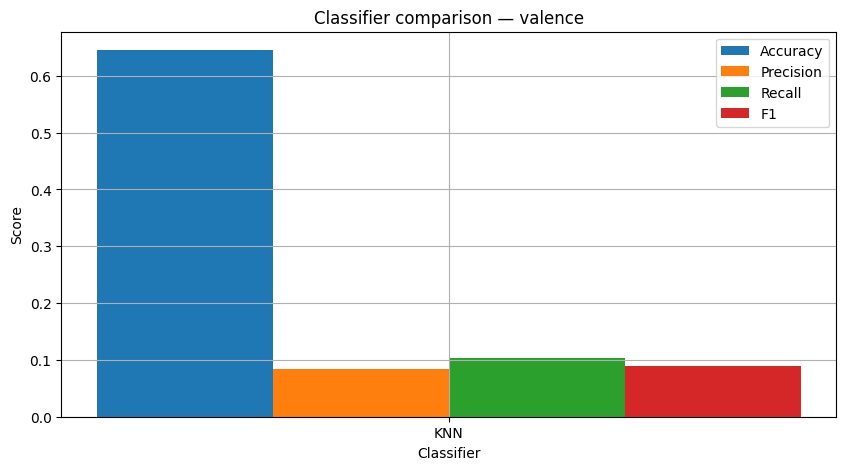


--- Arousal ---
 segment   label classifier  accuracy  precision   recall       f1
       1 arousal        KNN  0.625000   0.139864 0.208333 0.181911
       2 arousal        KNN  0.644231   0.149015 0.125000 0.105128
       3 arousal        KNN  0.620192   0.169028 0.166667 0.143463
       4 arousal        KNN  0.620192   0.169481 0.187500 0.155922


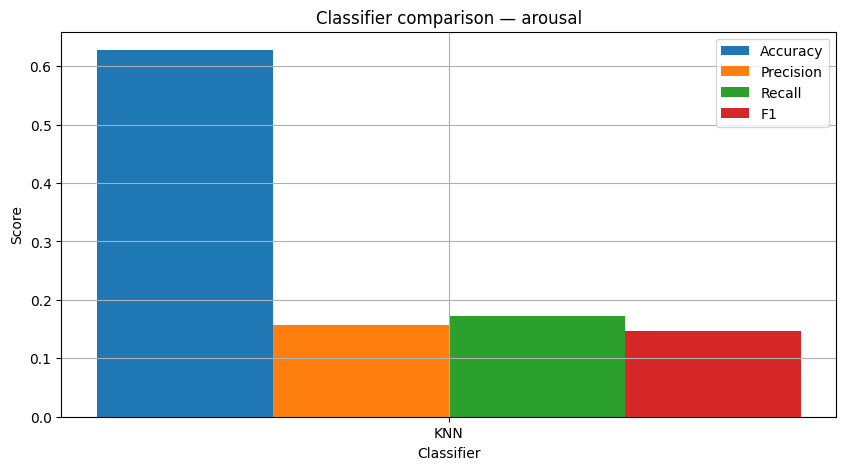


--- Dominance ---
 segment     label classifier  accuracy  precision   recall       f1
       1 dominance        KNN  0.264423   0.332175 0.246154 0.282738
       2 dominance        KNN  0.264423   0.343750 0.192308 0.230902
       3 dominance        KNN  0.288462   0.394397 0.229371 0.285608
       4 dominance        KNN  0.302885   0.412129 0.284615 0.332103


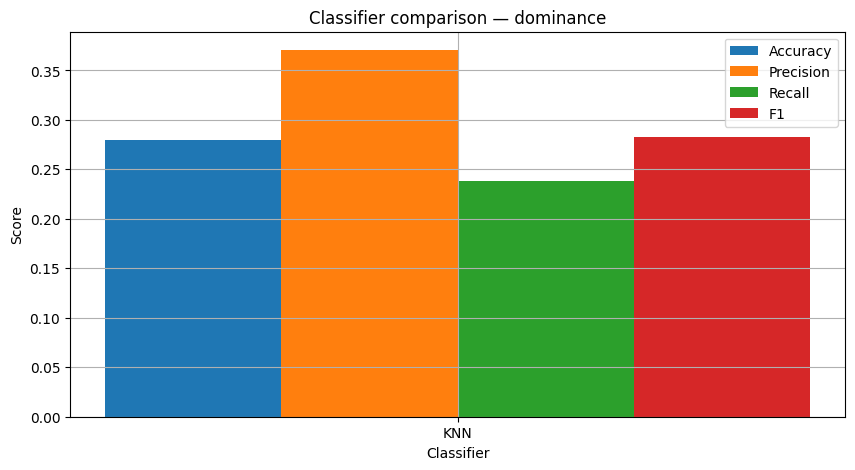


--- Liking ---
 segment  label classifier  accuracy  precision   recall       f1
       1 liking        KNN  0.413462   0.545726 0.505009 0.514900
       2 liking        KNN  0.432692   0.573593 0.521739 0.542289
       3 liking        KNN  0.355769   0.524306 0.318841 0.394628
       4 liking        KNN  0.399038   0.550874 0.427536 0.471216


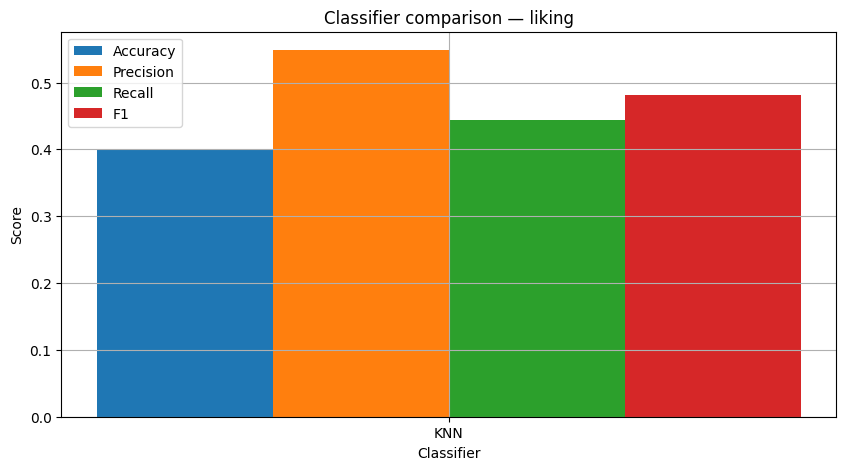

In [ ]:
# Build DataFrame from results
display_table = result_table.copy()

# Print and plot per label
for label in ["valence", "arousal", "dominance", "liking"]:
    subset = display_table[display_table["label"] == label]
    
    print(f"\n--- {label.capitalize()} ---")
    print(subset.to_string(index=False))
    
    plot_classifier_metrics(subset, title=f"Classifier comparison — {label}")

## Logistic Regression

Fits a linear decision boundary by modeling the log-odds of the positive class as a linear combination of the input features.

In [ ]:
mdl = LogisticRegression(max_iter=5000)

In [ ]:
result = run_model(mdl, segment_splits, "Logistic Regression")

result_table = pd.DataFrame(result)
results.extend(result)

print(len(results))

del(mdl)
del(result)

48



--- Valence ---
 segment   label classifier  accuracy  precision   recall       f1
       1 valence        KNN  0.644231   0.137500 0.183983 0.145555
       2 valence        KNN  0.600962   0.164332 0.232684 0.192379
       3 valence        KNN  0.639423   0.131944 0.208874 0.154386
       4 valence        KNN  0.701923   0.096875 0.091991 0.087814


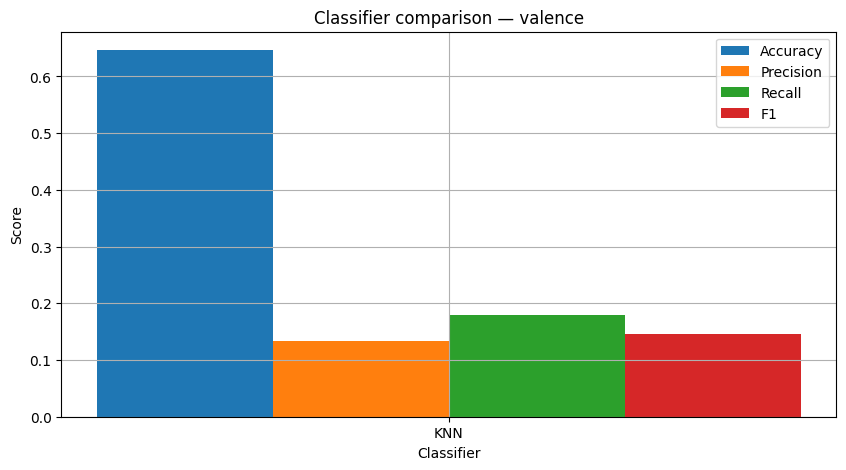


--- Arousal ---
 segment   label classifier  accuracy  precision   recall       f1
       1 arousal        KNN  0.759615   0.159515 0.062500 0.090000
       2 arousal        KNN  0.750000   0.088710 0.020833 0.034483
       3 arousal        KNN  0.764423   0.038462 0.020833 0.027027
       4 arousal        KNN  0.711538   0.085337 0.083333 0.080598


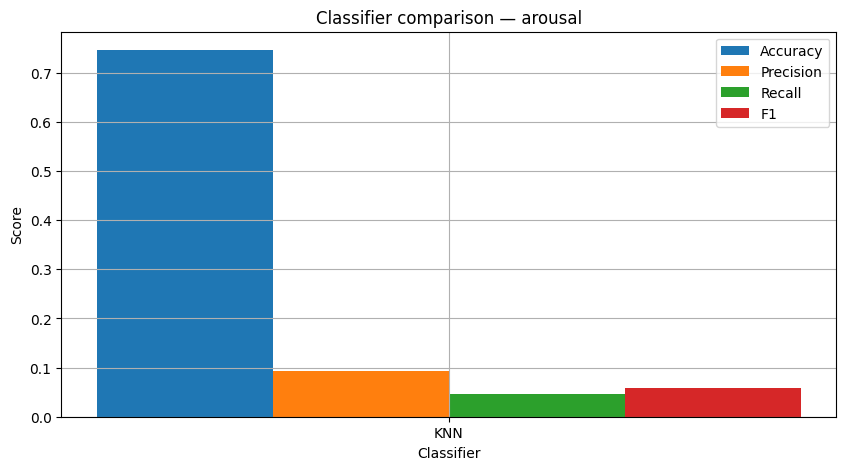


--- Dominance ---
 segment     label classifier  accuracy  precision   recall       f1
       1 dominance        KNN  0.379808   0.502680 0.602797 0.550083
       2 dominance        KNN  0.394231   0.512424 0.580420 0.565449
       3 dominance        KNN  0.389423   0.509259 0.550000 0.559684
       4 dominance        KNN  0.427885   0.538671 0.615385 0.573386


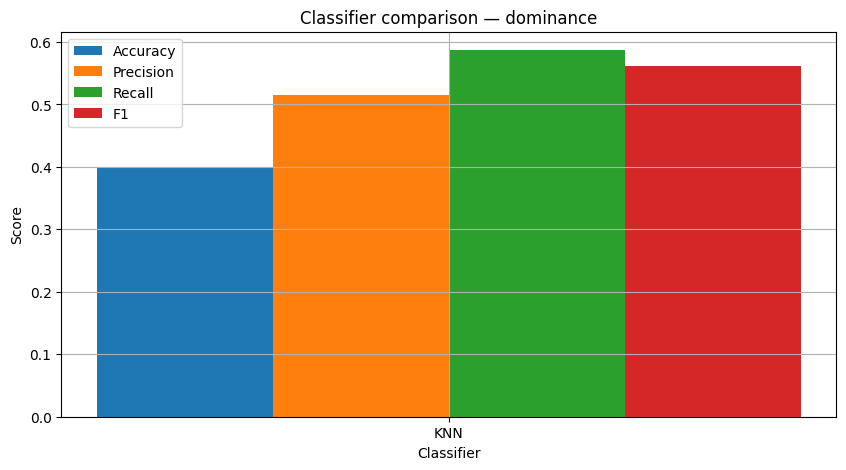


--- Liking ---
 segment  label classifier  accuracy  precision   recall       f1
       1 liking        KNN  0.528846   0.629085 0.724638 0.667080
       2 liking        KNN  0.538462   0.616667 0.724638 0.676847
       3 liking        KNN  0.514423   0.625169 0.695652 0.658040
       4 liking        KNN  0.485577   0.622841 0.543478 0.576698


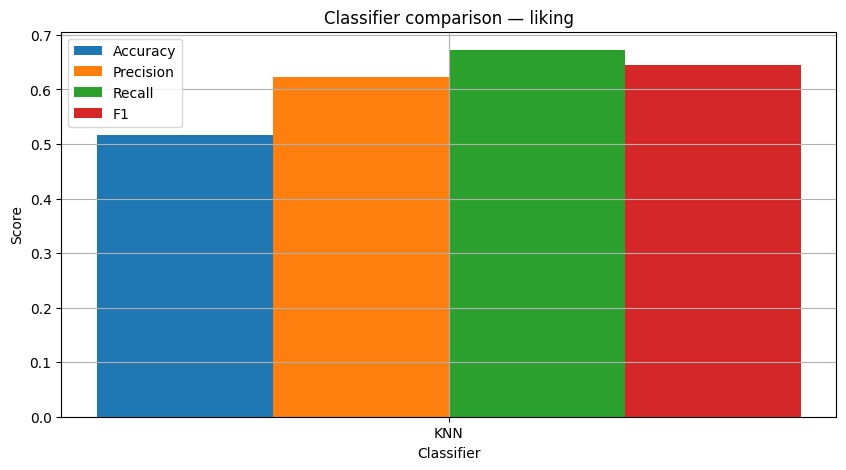

In [ ]:
# Build DataFrame from results
display_table = result_table.copy()

# Print and plot per label
for label in ["valence", "arousal", "dominance", "liking"]:
    subset = display_table[display_table["label"] == label]
    
    print(f"\n--- {label.capitalize()} ---")
    print(subset.to_string(index=False))
    
    plot_classifier_metrics(subset, title=f"Classifier comparison — {label}")

## Decision Tree (DecTree)

Learns a sequence of feature thresholds that split the training data into increasingly pure groups, forming a tree whose leaves predict a class.

In [ ]:
mdl = DecisionTreeClassifier()

In [ ]:
result = run_model(mdl, segment_splits, "Decision Tree")

result_table = pd.DataFrame(result)
results.extend(result)

print(len(results))

del(result)
del(mdl)

64



--- Valence ---
 segment   label classifier  accuracy  precision   recall       f1
       1 valence        KNN  0.485577   0.197561 0.250000 0.244429
       2 valence        KNN  0.519231   0.199678 0.349567 0.245029
       3 valence        KNN  0.524038   0.147568 0.232684 0.209724
       4 valence        KNN  0.500000   0.129320 0.255411 0.189177


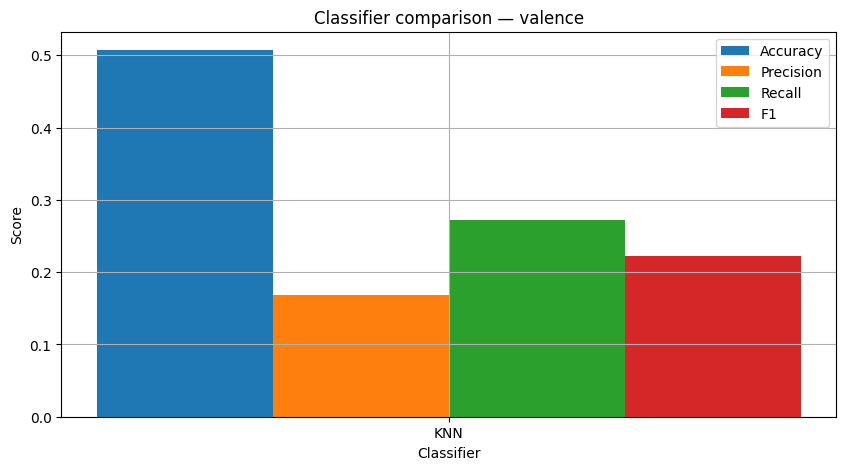


--- Arousal ---
 segment   label classifier  accuracy  precision   recall       f1
       1 arousal        KNN  0.500000   0.185676 0.250000 0.189530
       2 arousal        KNN  0.576923   0.188406 0.250000 0.209957
       3 arousal        KNN  0.538462   0.235385 0.416667 0.291101
       4 arousal        KNN  0.528846   0.176495 0.229167 0.266691


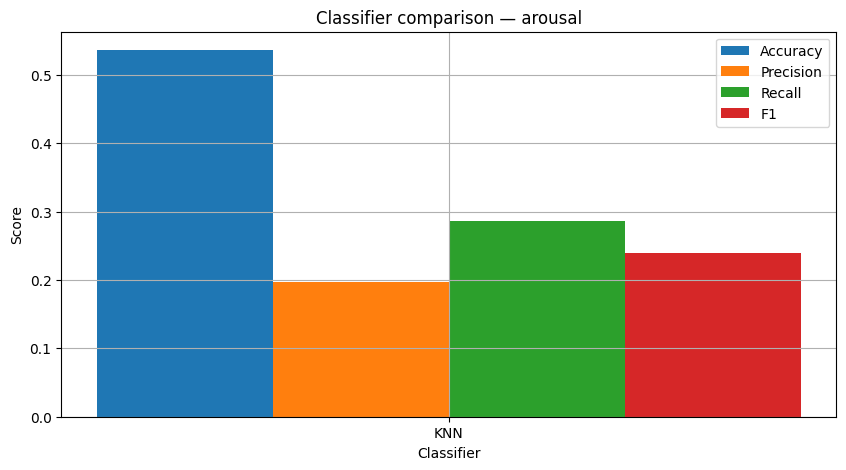


--- Dominance ---
 segment     label classifier  accuracy  precision   recall       f1
       1 dominance        KNN  0.293269   0.430526 0.300000 0.385465
       2 dominance        KNN  0.312500   0.387500 0.284615 0.351078
       3 dominance        KNN  0.326923   0.477743 0.276923 0.336816
       4 dominance        KNN  0.288462   0.373308 0.269231 0.334873


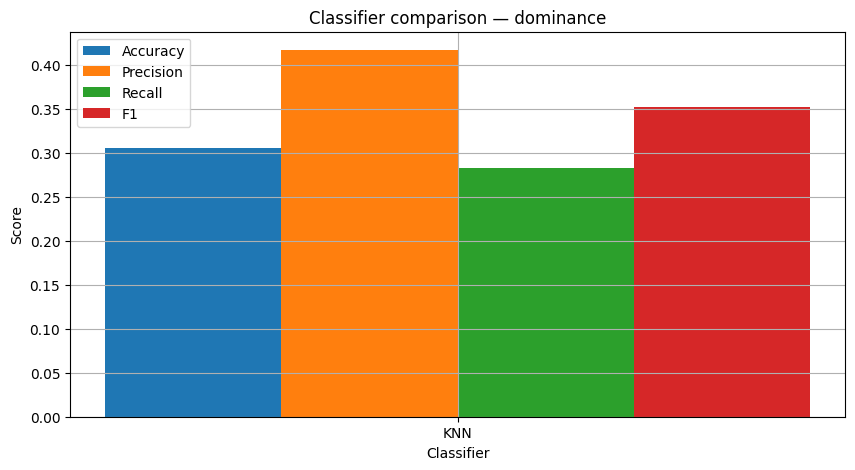


--- Liking ---
 segment  label classifier  accuracy  precision   recall       f1
       1 liking        KNN  0.432692   0.553714 0.478261 0.493162
       2 liking        KNN  0.379808   0.534314 0.408568 0.485941
       3 liking        KNN  0.384615   0.552585 0.384058 0.491377
       4 liking        KNN  0.288462   0.483333 0.239130 0.341728


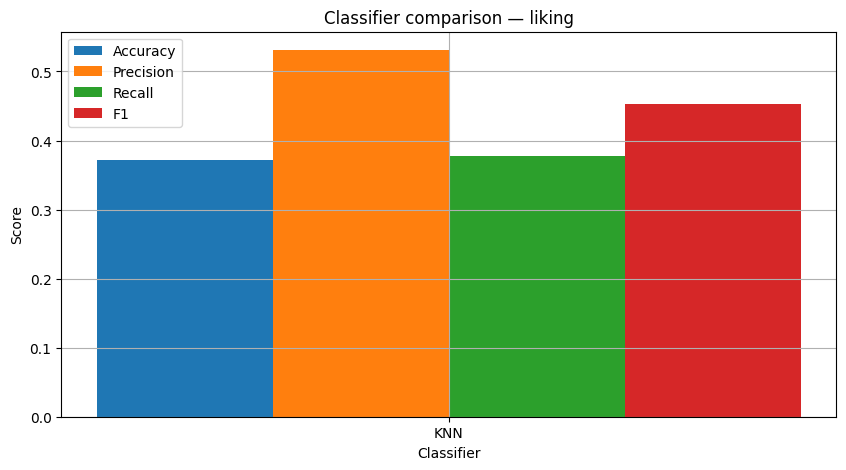

In [ ]:
# Build DataFrame from results
display_table = result_table.copy()

# Print and plot per label
for label in ["valence", "arousal", "dominance", "liking"]:
    subset = display_table[display_table["label"] == label]
    
    print(f"\n--- {label.capitalize()} ---")
    print(subset.to_string(index=False))
    
    plot_classifier_metrics(subset, title=f"Classifier comparison — {label}")

## LDA (Linear Discriminant Analysis)

 Projects the data onto the direction that best separates the two classes by maximizing between-class variance relative to within-class variance.

In [ ]:
mdl = LinearDiscriminantAnalysis()

In [ ]:
result = run_model(mdl, segment_splits, "LDA")

result_table = pd.DataFrame(result)
results.extend(result)

print(len(results))

del(result)
del(mdl)

80



--- Valence ---
 segment   label classifier  accuracy  precision   recall       f1
       1 valence        KNN  0.615385   0.158333 0.207792 0.168203
       2 valence        KNN  0.634615   0.162281 0.232684 0.188746
       3 valence        KNN  0.634615   0.133929 0.163420 0.133333
       4 valence        KNN  0.692308   0.071078 0.091991 0.071399


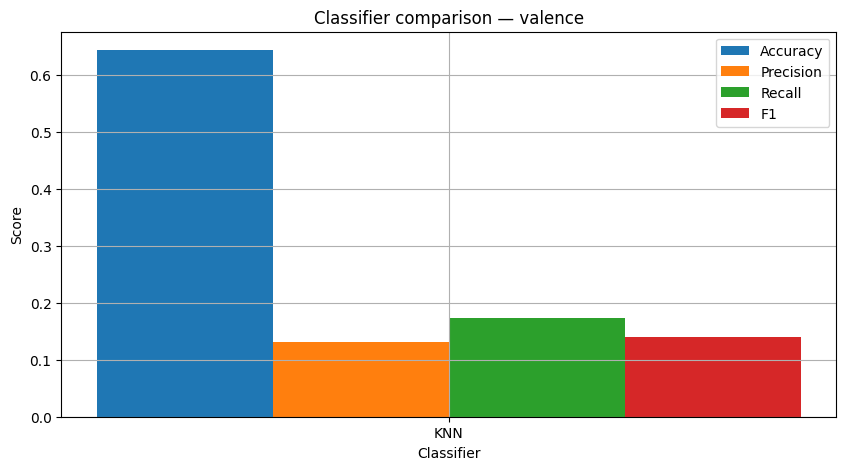


--- Arousal ---
 segment   label classifier  accuracy  precision   recall       f1
       1 arousal        KNN  0.706731   0.200247 0.062500 0.116923
       2 arousal        KNN  0.735577   0.128788 0.041667 0.067816
       3 arousal        KNN  0.764423   0.071429 0.020833 0.040000
       4 arousal        KNN  0.725962   0.091667 0.062500 0.077031


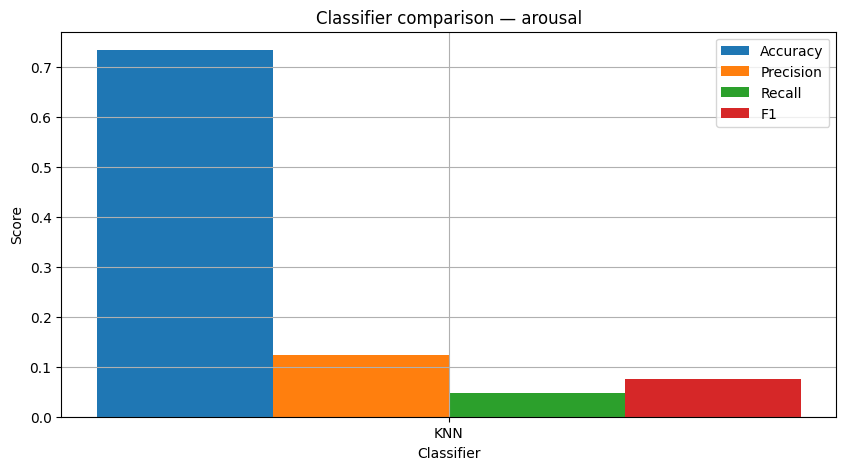


--- Dominance ---
 segment     label classifier  accuracy  precision   recall       f1
       1 dominance        KNN  0.389423   0.512684 0.572611 0.555277
       2 dominance        KNN  0.413462   0.524390 0.568182 0.585034
       3 dominance        KNN  0.389423   0.509259 0.530769 0.536364
       4 dominance        KNN  0.423077   0.531411 0.530769 0.533421


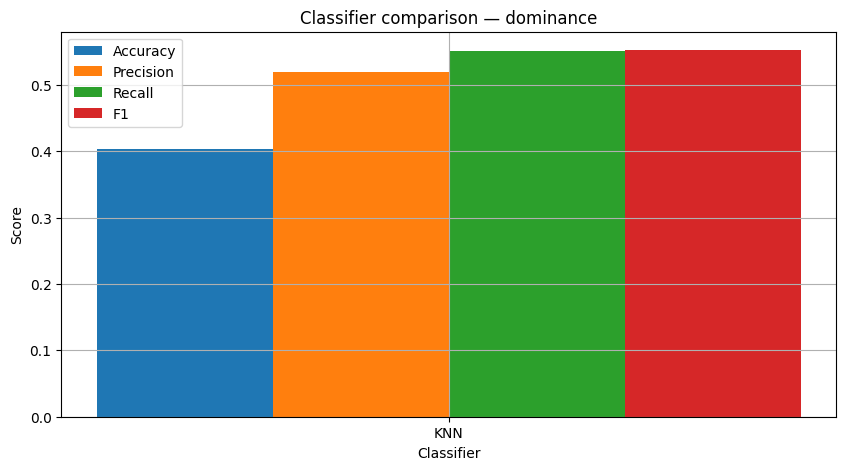


--- Liking ---
 segment  label classifier  accuracy  precision   recall       f1
       1 liking        KNN  0.548077   0.637001 0.760870 0.684327
       2 liking        KNN  0.548077   0.620894 0.804348 0.706239
       3 liking        KNN  0.538462   0.647819 0.702899 0.660397
       4 liking        KNN  0.500000   0.629028 0.637681 0.616243


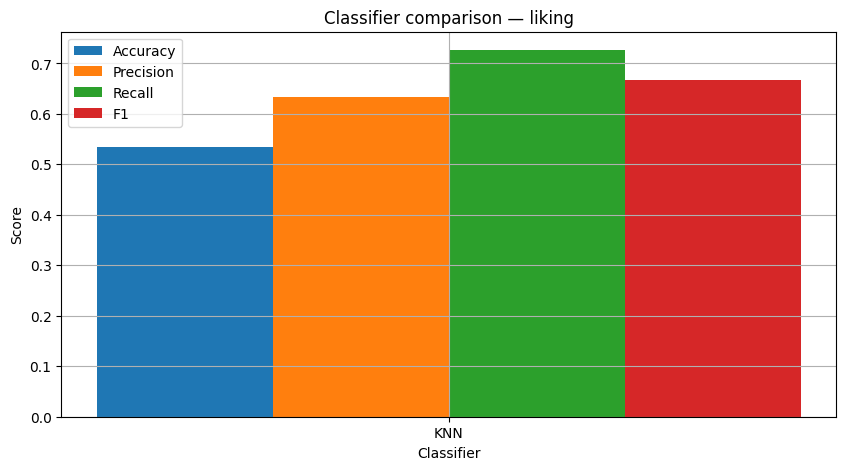

In [ ]:
# Build DataFrame from results
display_table = result_table.copy()

# Print and plot per label
for label in ["valence", "arousal", "dominance", "liking"]:
    subset = display_table[display_table["label"] == label]
    
    print(f"\n--- {label.capitalize()} ---")
    print(subset.to_string(index=False))
    
    plot_classifier_metrics(subset, title=f"Classifier comparison — {label}")

# Results
---

Collects every classifier's result from `results` into a single table, reports the best model by F1 score, and plots a bar chart comparing F1 across all of them.

In [ ]:
print(len(results))

# Build DataFrame from results
result_table = pd.DataFrame(results)
display_table = result_table.copy()

80
SVMSVMSVMSVMSVMSVMSVMSVMSVMSVMSVMSVMSVMSVMSVMSVMKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNNKNN

In [ ]:
# Best model
best_index = result_table["f1"].idxmax()

print("\nBEST MODEL\n")
print(display_table.loc[best_index])


BEST MODEL

segment              2
label           liking
classifier         SVM
accuracy      0.658654
precision     0.663462
recall             1.0
f1            0.794193
Name: 7, dtype: object



--- Valence ---
 segment   label classifier  accuracy  precision   recall       f1
       1 valence        SVM  0.788462   0.000000 0.000000 0.000000
       2 valence        SVM  0.788462   0.000000 0.000000 0.000000
       3 valence        SVM  0.788462   0.000000 0.000000 0.000000
       4 valence        SVM  0.788462   0.000000 0.000000 0.000000
       1 valence        KNN  0.610577   0.112698 0.113636 0.112444
       2 valence        KNN  0.610577   0.094118 0.091991 0.085829
       3 valence        KNN  0.677885   0.063946 0.093074 0.077945
       4 valence        KNN  0.682692   0.063946 0.116883 0.081319
       1 valence        KNN  0.644231   0.137500 0.183983 0.145555
       2 valence        KNN  0.600962   0.164332 0.232684 0.192379
       3 valence        KNN  0.639423   0.131944 0.208874 0.154386
       4 valence        KNN  0.701923   0.096875 0.091991 0.087814
       1 valence        KNN  0.500000   0.190952 0.272727 0.224387
       2 valence        KNN  0.533654   0.193

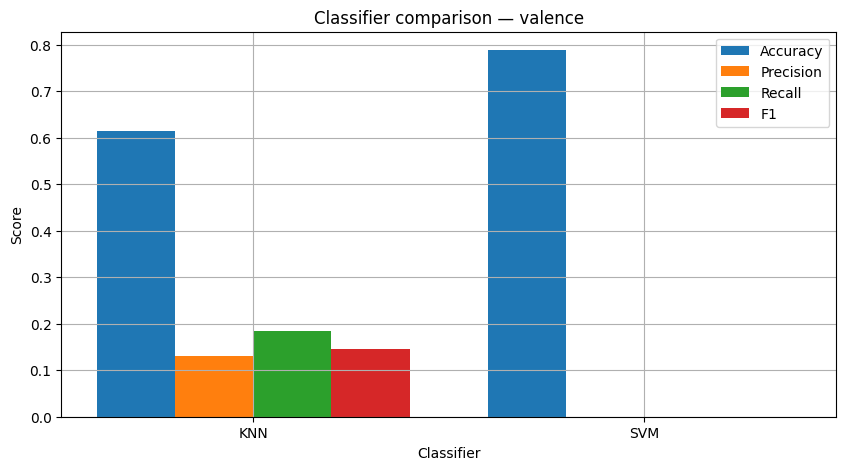


--- Arousal ---
 segment   label classifier  accuracy  precision   recall       f1
       1 arousal        SVM  0.769231   0.000000 0.000000 0.000000
       2 arousal        SVM  0.769231   0.000000 0.000000 0.000000
       3 arousal        SVM  0.769231   0.000000 0.000000 0.000000
       4 arousal        SVM  0.769231   0.000000 0.000000 0.000000
       1 arousal        KNN  0.625000   0.139864 0.208333 0.181911
       2 arousal        KNN  0.644231   0.149015 0.125000 0.105128
       3 arousal        KNN  0.620192   0.169028 0.166667 0.143463
       4 arousal        KNN  0.620192   0.169481 0.187500 0.155922
       1 arousal        KNN  0.759615   0.159515 0.062500 0.090000
       2 arousal        KNN  0.750000   0.088710 0.020833 0.034483
       3 arousal        KNN  0.764423   0.038462 0.020833 0.027027
       4 arousal        KNN  0.711538   0.085337 0.083333 0.080598
       1 arousal        KNN  0.471154   0.162338 0.208333 0.191028
       2 arousal        KNN  0.591346   0.189

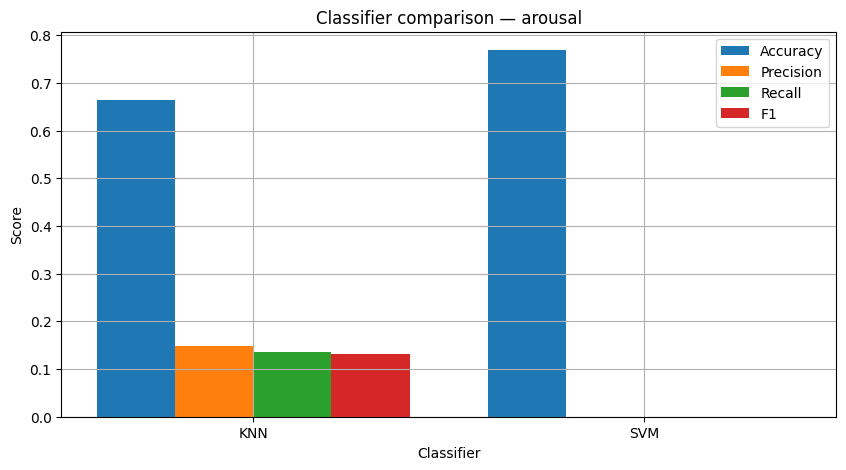


--- Dominance ---
 segment     label classifier  accuracy  precision   recall       f1
       1 dominance        SVM  0.543269   0.594637 0.862471 0.703937
       2 dominance        SVM  0.581731   0.611122 0.878788 0.735551
       3 dominance        SVM  0.567308   0.605114 0.900932 0.723878
       4 dominance        SVM  0.600962   0.619431 0.901166 0.739507
       1 dominance        KNN  0.264423   0.332175 0.246154 0.282738
       2 dominance        KNN  0.264423   0.343750 0.192308 0.230902
       3 dominance        KNN  0.288462   0.394397 0.229371 0.285608
       4 dominance        KNN  0.302885   0.412129 0.284615 0.332103
       1 dominance        KNN  0.379808   0.502680 0.602797 0.550083
       2 dominance        KNN  0.394231   0.512424 0.580420 0.565449
       3 dominance        KNN  0.389423   0.509259 0.550000 0.559684
       4 dominance        KNN  0.427885   0.538671 0.615385 0.573386
       1 dominance        KNN  0.302885   0.467204 0.315385 0.340942
       2 domina

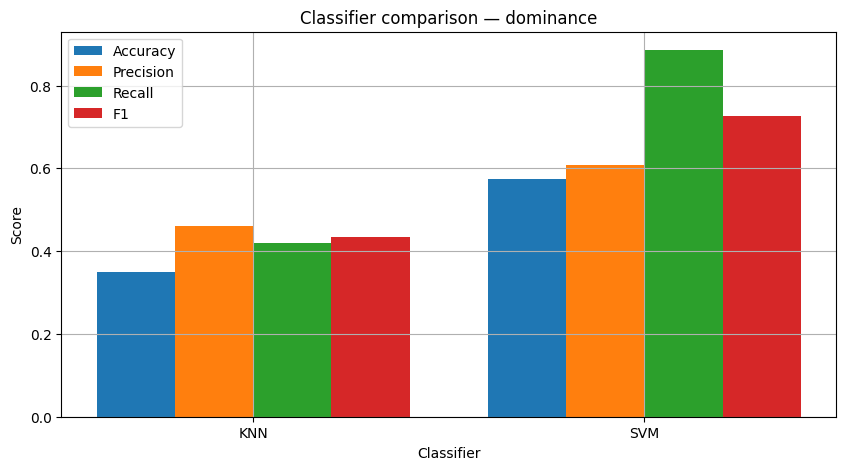


--- Liking ---
 segment  label classifier  accuracy  precision   recall       f1
       1 liking        SVM  0.644231   0.658960 0.971014 0.779964
       2 liking        SVM  0.658654   0.663462 1.000000 0.794193
       3 liking        SVM  0.658654   0.663462 0.978261 0.794193
       4 liking        SVM  0.649038   0.662613 0.985507 0.787162
       1 liking        KNN  0.413462   0.545726 0.505009 0.514900
       2 liking        KNN  0.432692   0.573593 0.521739 0.542289
       3 liking        KNN  0.355769   0.524306 0.318841 0.394628
       4 liking        KNN  0.399038   0.550874 0.427536 0.471216
       1 liking        KNN  0.528846   0.629085 0.724638 0.667080
       2 liking        KNN  0.538462   0.616667 0.724638 0.676847
       3 liking        KNN  0.514423   0.625169 0.695652 0.658040
       4 liking        KNN  0.485577   0.622841 0.543478 0.576698
       1 liking        KNN  0.413462   0.581061 0.442029 0.493964
       2 liking        KNN  0.360577   0.548872 0.386509 0.4

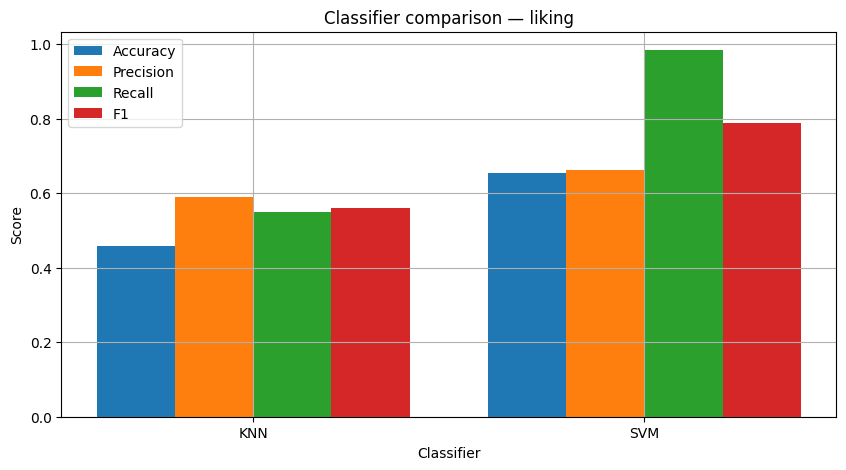

In [ ]:
# Print and plot per label
for label in ["valence", "arousal", "dominance", "liking"]:
    subset = display_table[display_table["label"] == label]
    
    print(f"\n--- {label.capitalize()} ---")
    print(subset.to_string(index=False))
    
    plot_classifier_metrics(subset, title=f"Classifier comparison — {label}")